In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']

[*********************100%***********************]  1 of 1 completed


In [3]:
# calculo de rendimeintos y volatilidad 
daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()
sigma = daily_returns.std() * np.sqrt(252)

In [4]:
#definimos parametros necesarios para la simulacion

S0 = data.iloc[-1]  # Precio spot actual
r = 0.08            # Tasa libre de riesgo
T = 100 / 365       # Tiempo al vencimiento en años

num_simulations = 10000

In [5]:
# generamos variables aleatorias 
Z = np.random.normal(0, 1, num_simulations)

In [6]:
# simulacion del precio del futuro 
St = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

In [7]:
# calculo de pagos de opciones 

K = 680

In [9]:
# calculo del call y el puto para  cada simulacion 
call = np.maximum(St - K, 0)
put = np.maximum(K - St, 0)

In [10]:
# calcular el valor presente de las acciones 
call_value = np.exp(-r * T) * np.mean(call)
put_value = np.exp(-r * T) * np.mean(put)

In [11]:
# resultados  o calculo del payyoff 

call_value
put_value

np.float64(19.483096616822642)

In [16]:
K_values = [640, 660, 680, 700, 720]

In [21]:


# listas para guardar resultados
call_prices = []
put_prices = []

for K in K_values:
    
    # payoff
    call = np.maximum(St - K,0)
    put = np.maximum(K - St,0)
    
    # precio descontado o valor presente de la accion 
    call_value = np.exp(-r*T) * np.mean(call)
    put_value = np.exp(-r*T) * np.mean(put)
    
    # guardar
    call_prices.append(call_value)
    put_prices.append(put_value)

# crear tabla
results = pd.DataFrame({
    "Strike": K_values,
    "Call Price": call_prices,
    "Put Price": put_prices
})

print(results)

   Strike  Call Price  Put Price
0     640   57.470800   6.818827
1     660   43.140440  12.054881
2     680   31.002243  19.483097
3     700   21.309210  29.356477
4     720   13.935613  41.549293


Aumenta o disminuye el valor de la opción conforme aumenta K?
Disminuye el valor de la accion 

¿Qué ocurre cuando el strike es relativamente muy alto? ¿Cuando es muy bajo?

 Cuaan es muy alto el precio de la ccion baja, cuando es muy bajo el precio de laccion disminuye. 



In [25]:
# valores a probar
K_values = [640,660,680,700,720]
r_values = [0.01,0.05,0.10]

results = []

for r in r_values:
    
    # recalcular St porque r cambia el drift
    St = S0 * np.exp((r - 0.5 * sigma**2)*T + sigma*np.sqrt(T)*Z)
    
    for K in K_values:
        
        call = np.maximum(St - K,0)
        put = np.maximum(K - St,0)

        call_value = np.exp(-r*T) * np.mean(call)
        put_value = np.exp(-r*T) * np.mean(put)

        results.append([r,K,call_value,put_value])

# tabla final
df = pd.DataFrame(results, columns=["r","Strike","Call Price","Put Price"])

print(df)

       r  Strike  Call Price  Put Price
0   0.01     640   48.341355   9.813147
1   0.01     660   35.118708  16.535781
2   0.01     680   24.348194  25.710548
3   0.01     700   16.067621  37.375255
4   0.01     720   10.047484  51.300399
5   0.05     640   53.478583   7.994053
6   0.05     660   39.605115  13.848480
7   0.05     680   28.031845  22.003105
8   0.05     700   18.945446  32.644602
9   0.05     720   12.160834  45.587885
10  0.10     640   60.189444   6.116031
11  0.10     660   45.569879  10.955959
12  0.10     680   33.083580  17.929153
13  0.10     700   22.978545  27.283610
14  0.10     720   15.209707  38.974265


¿Cómo cambia el crecimiento esperado del precio del activo?
el precio aumenta  cuando la tasa disminuye y baja cuando la tasa aumenta



¿Qué sucede con el valor de la call cuando aumenta la tasa libre de riesgo? sigue aun disminuyen mas 



¿Qué sucede con el valor de la put cuando aumenta la tasa libre de riesgo? En este caso si aumenta el put cuando la tasa de interes lo hace. 

In [26]:
call_matrix = df.pivot(index="r", columns="Strike", values="Call Price")
put_matrix = df.pivot(index="r", columns="Strike", values="Put Price")

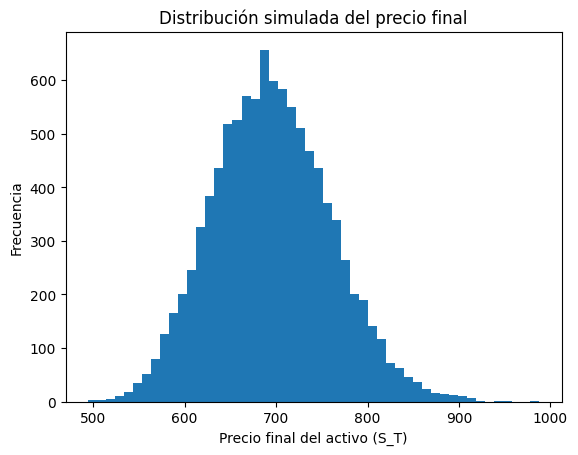

In [28]:
plt.hist(St, bins=50)

plt.xlabel("Precio final del activo (S_T)")
plt.ylabel("Frecuencia")
plt.title("Distribución simulada del precio final")

plt.show()